# 1. Adathalmaz feltérképezése

**A feladat értelmezése:**
A feladatom egy arcfelismerő neurális háló létrehozása volt. A háló feladata,    hogy képes legyen felismerni, vagyis klasszifikálni egy adott személyt. Ebből adódik, hogy ez egy osztályozási probléma, ahol minden egyes személy 1-1 osztálytnak felel meg.

**Az adatbázis:** A University of Massachusetts, Amherst (UMASS): Labelled Faces in the Wild (LFW) adatbázist használtam, pontosabban a kaggle-ön található, *deep-funneled* verzióját.
(https://www.kaggle.com/datasets/jessicali9530/lfw-dataset)

Deep funneling: a képeket egy speciális előkészítési, ún. igazítási (alignment) folyamaton engedték át, mielőtt véglegesítették azokat a dataset-ben. Ennek célja:

1.   **Standardizálás**:
Minden arcot egy egységes méretre, központra és orientációra hoztak.
2.   **Póz és Elhelyezkedés Korrekciója**

Deep funneling folyamata:

1.   **Arckivágás**: arc megkeresése a képen
2.   **Referenciapontok azonosítása**: kulcsfontosságú arcpontok például szemek sarkai, orr csúcsa, száj sarkai stb.
3.   **Geometriai transzformáció**: formázás, skálázás, elforgatás, eltolás. Emiatt ugyanolyan pozícióban lesznek a képek.

Mindezt deep learning modell végzi (Viola-Jones arcdetektor) természetesen.

**A fáljokról**: A kapott fájlcsomagom tehát egy mapparendszer, melyben minden mappa címe egy személy neve, hiszen egy mappa egy osztály. A mappákban pedig az adott személyhez tartozó összes fotó szerepelt. Látszott rajtuk a deep funneling hatása, ami segítségével jobb eredményű modellt tudtam készíteni.


*   **A képek mérete**: 250 x 250 pixel (formátuma .jpg)
*  **Az adat mennyisége**: Nagy adatbázis, és nagyon sok osztály: 13233 kép, 5749 szeméylről. (Ezekből 1680 személy rendelkezik 1-nél több fotóval)

Az adatbázis vizsgálata után választottam ki a Google Collab-ot, mint fejlesztői felület, hiszen könnyen kezelhető a google drive segítségével a mapparendszer. De ami fontosabb: a képfeldolgozás magas GPU igényű, a feladathoz a google T4-es futtatókörnyezetére volt szükségem.
A keretrendszerem pedig a Tensorflow/Keras.




# 2-3. Megfelelő neurális háló létrehozása és az adatelőkészítés

Az adatelőkészítés a neurális háló létrehozásával együttesen történt.
Először kiválaszottam az adatkészlet felosztását a training set, validation set és test set között. A **80/10/10** -re esett a választásom. Meghatároztam egy batch méretét: 32-essével dolgozza fel a képeket.
A képek méretének konvertálása: az eredeti 250x250 ről 224x224-esre átméretetzem, hiszen a MobilNetV2 alapértelmezett input shape-je: (224,224,3). A MobilNetV2 egy Keras-on belüli architektúra, erre esett a választásom. https://keras.io/api/applications/mobilenet/

In [46]:
#-----------------------IMPORTOK ÉS DEFINÍCIÓK------------------------

import os
import tensorflow as tf
from tensorflow import keras
import shutil

# A MobileNetV2 alkalmazás beimportálása
from tensorflow.keras.applications import MobileNetV2

# A modell felépítéséhez szükséges fő komponensek
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

from google.colab import drive
drive.mount("/content/drive")

# A mappában lévő adatok gyökérkönyvtára
DATA_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled"
BEST_MODEL_DRIVE_DIR= "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

os.makedirs( BEST_MODEL_DRIVE_DIR, exist_ok=True) #létrehozza itt

# ----------------- Képfeldolgozási Konstansok -----------------
# Célfelbontás (Resizing)
IMG_WIDTH = 224
IMG_HEIGHT = 224
# A tanítási adatok betöltésekor egyszerre felhasznált képek száma
BATCH_SIZE = 32
# A felosztáshoz használt százalék
VAL_SPLIT = 0.2  # 10% a teszthez és validációhoz összesen

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Betöltöttem a train és validation adatokat úgy, hogy a mappák nevei lettek a címkék, az új méret legyen a képméret, és a validációs felosztást használja. Félreteszi a 20%-ot a validációs+test adatoknak. Létrehoztam a NUM_CLASSES nevű változót az osztályszám ellenőrzésére.
Eredményül látható, hogy a felosztás képek számával: 10587/2646

In [47]:
# ---------------TRAIN és VALIDATION adatok betöltése------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=DATA_DIR,
    labels='inferred', # A mappa nevei a címkék
    label_mode='categorical', # One-Hot Encoding (a 250+ osztályhoz)
    image_size=(IMG_HEIGHT, IMG_WIDTH), # Átméretezés 250x250-ről 128x128-ra
    interpolation='bilinear', # Átméretezési módszer
    batch_size=BATCH_SIZE,
    shuffle=True, # Fontos a randomizálás a tanításhoz
    validation_split=VAL_SPLIT,
    subset='training', # A 80%-os tanító rész
    seed=42 # Random seed a reprodukálhatósághoz
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory=DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset='validation', # A 20%-os validációs+teszt rész
    seed=42
)

# A létrehozott osztályok nevei
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Az osztályok száma (felismerendő személyek): {NUM_CLASSES}")

Found 13233 files belonging to 5749 classes.
Using 10587 files for training.
Found 13233 files belonging to 5749 classes.
Using 2646 files for validation.
Az osztályok száma (felismerendő személyek): 5749


Most pedig a félretett 20%-ot osztjuk tovább felezve, ezért elég volt minden második adat kihagyásával elkülöníteni a validation és test adatokat. Éppen ezért jól lettek "megkeverve". A tanító batch-ek száma 331 lett (hiszen 10587/32 kb 331). A többi hasonlóan.

In [48]:
# Osszuk fel a 20%-os VALIDÁCIÓS készletet 10%-os validációs és 10%-os teszt készletekre.

# Meghatározzuk a kettéosztás arányát (a 20%-os résznek a felét, azaz 0.5-öt)
val_batches = tf.data.experimental.cardinality(validation_ds)
test_ds = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Tanító készlet mérete (batches): {tf.data.experimental.cardinality(train_ds)}")
print(f"Validációs készlet mérete (batches): {tf.data.experimental.cardinality(validation_ds)}")
print(f"Teszt készlet mérete (batches): {tf.data.experimental.cardinality(test_ds)}")

Tanító készlet mérete (batches): 331
Validációs készlet mérete (batches): 42
Teszt készlet mérete (batches): 41


Kivettem az első batch-et ellenőrzésnek, hogy a pixel értékeket vizsgáljam. A döntés az volt, hogy az átméretezés ne az inputlayernél történjen, hanem csak majd az első layernél.

In [49]:
# Vegyük ki az első batch-et (32 kép és a hozzájuk tartozó címkék)  # a méretnek még 0-255 közé kell esnie,
# a háló első rétege fogja végezni a rescalinget!
for images, labels in train_ds.take(1):
    # A képek méretének ellenőrzése
    print(f"Képek Shape (mérete): {images.shape}")

    # A normalizálás ellenőrzése (az értékeknek 0 és 1 között kell lenniük)
    print(f"Első kép (pixel értékek) minimum: {images[0].numpy().min()}")
    print(f"Első kép (pixel értékek) maximum: {images[0].numpy().max()}")
    break

Képek Shape (mérete): (32, 224, 224, 3)
Első kép (pixel értékek) minimum: 0.0
Első kép (pixel értékek) maximum: 255.0


További ellenőrzések 6 pontban, a futtatás előtt, a shape-ről, az adattípusról, valamint a nyers pixelméretekről. Ehhez első batch, majd első batch címkéinek vizsgálata. Majd első címke One-Hot kódolva: végigmegy az oszályokon: 0, ha nem találat, 1, ha találat, tehát pontosan egyszer kell 1-nek lennie. Kiírhatnánk hosszasan is, de most a lenormálás érdekelt 0 és 1 közé.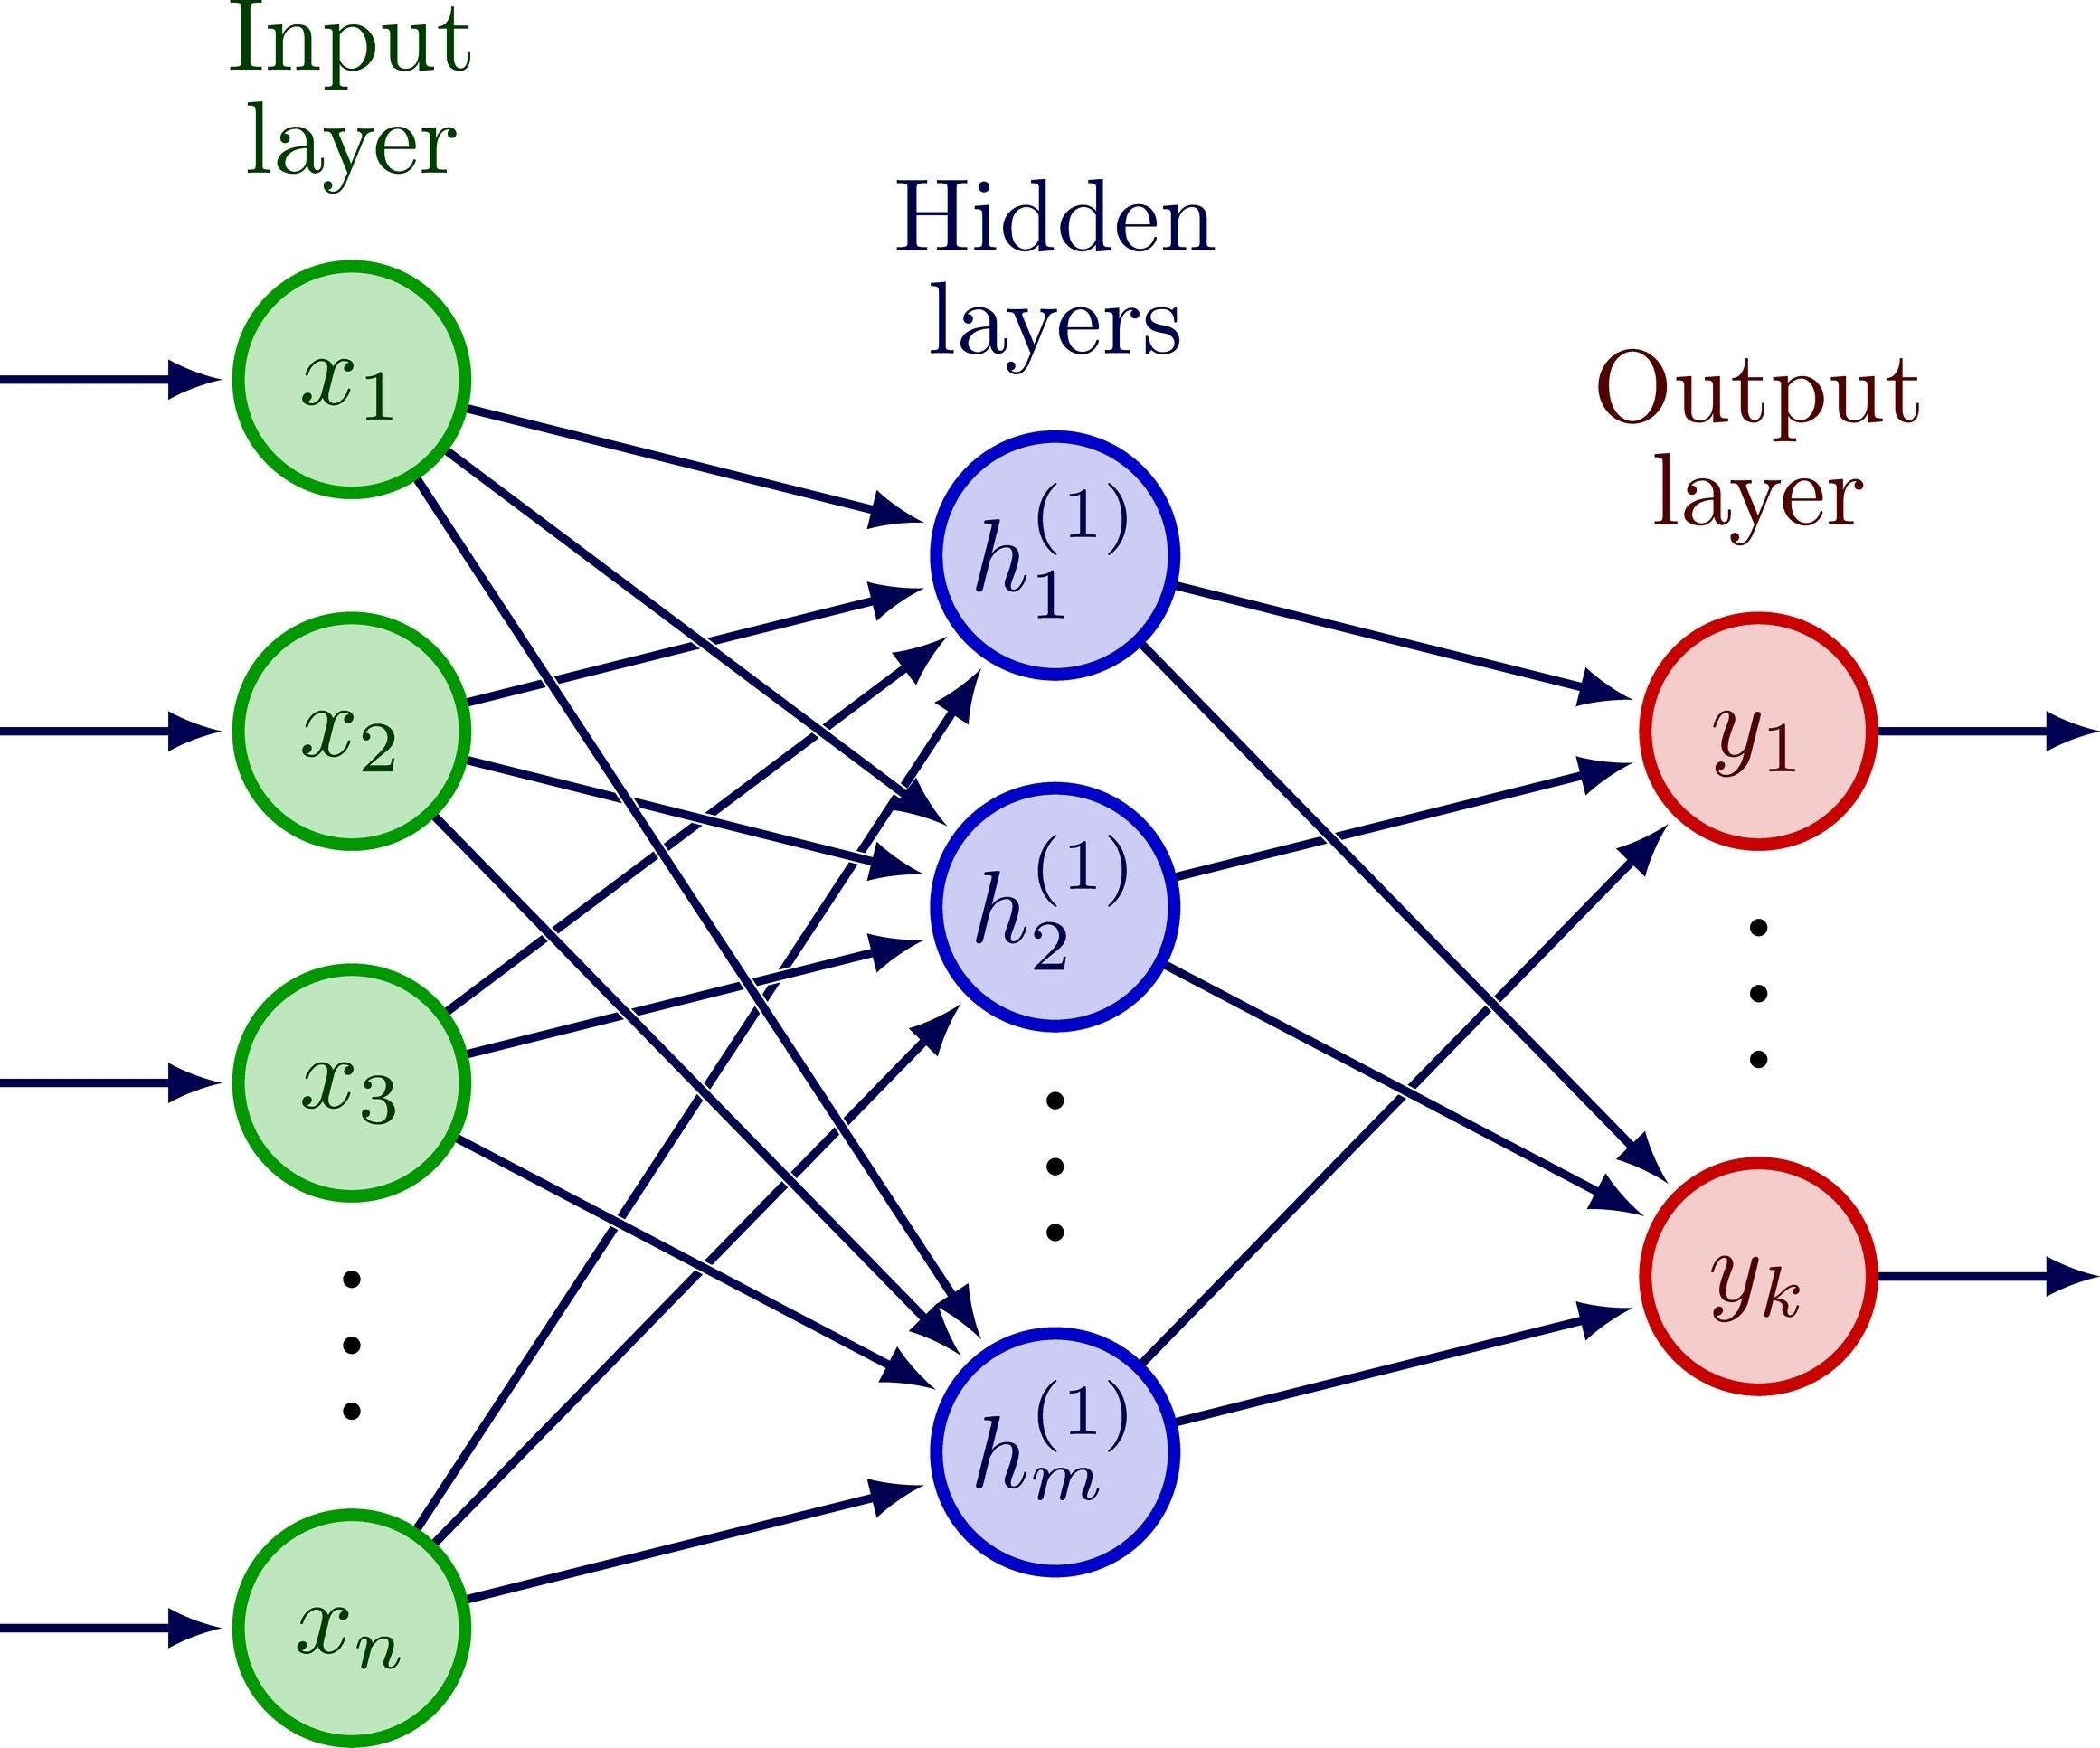

In [50]:
# Vegyük ki az első batch-et a train_ds-ből
for images, labels in train_ds.take(1):

    # 1. Bemeneti Méret / Alak Ellenőrzése
    print(f"1. Train_DS Batch Mérete (shape): {images.shape}")

    # 2. Adattípus Ellenőrzése
    print(f"2. Adattípus (dtype): {images.dtype}")

    # 3. Normalizálás Ellenőrzése (Nyers adatokon, 0-255)
    # Ez a CÉL: a háló kapja meg a 0-1 tartományt, de a train_ds még 0-255
    print(f"3. Nyers Pixel Max (Train_DS): {images[0].numpy().max()}")

    # 4. Ellenőrzés a Rescaling réteg után:
    # Mivel a Rescaling a modellben van, csak a 3. lépés (MobileNetV2) futtatása után indul el
    # Ha a 3. lépés helyesen lefutott (a Rescaling réteggel), akkor ez a 3. pont rendben van.

    break

1. Train_DS Batch Mérete (shape): (32, 224, 224, 3)
2. Adattípus (dtype): <dtype: 'float32'>
3. Nyers Pixel Max (Train_DS): 255.0


In [51]:
# Vizsgáljuk meg az első batch címkéit
for images, labels in train_ds.take(1):
    # 1. Címkék alakjának (shape) ellenőrzése
    # A formátumnak (BATCH_SIZE, NUM_CLASSES) kell lennie.
    print(f"4. Címkék Shape (Batch méret, Osztályok száma): {labels.shape}")

    # 2. Ellenőrizzük az első címke tartalmát
    # Minden címke egy vektor, amelyben egy darab 1.0 és sok 0.0 van.
    first_label = labels.numpy()[0]
    print(f"5. Első címke (One-Hot kódolt): a vektor első 10 eleme: {first_label[:10]}")

    # 3. Ellenőrizzük, hogy csak 0 és 1 értékek vannak-e benne, és csak egy egyes van a vektorban
    # Ez igazolja, hogy a 'categorical' label_mode rendben működik.
    if (first_label.min() >= 0.0 and
        first_label.max() <= 1.0 and
        first_label.sum() == 1.0):
        print("6. One-Hot Encoding ellenőrzés: SIKERES")
    else:
        print("6. One-Hot Encoding ellenőrzés: HIBA")
    break

4. Címkék Shape (Batch méret, Osztályok száma): (32, 5749)
5. Első címke (One-Hot kódolt): a vektor első 10 eleme: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
6. One-Hot Encoding ellenőrzés: SIKERES


**Epoch-szám meghatározása és a türelmi idő**  : 1 epoch alatt végigfut a háló egyszer, ennek maximális számot állítunk, valamint EarlyStopping módszert alkalmazunk: 5 epoch-ot vár, vizsgálja, volt-e javulás, és ha nem volt: leállítja a tanulást. A vizsgált paramétere: validációs veszteség.
(validációs adatok eltérése az előírttól, ennek célja 0)

**Checkpointok**: a biztonságos mentéshez mindig eltesszük az aktuális legjobb modell, vagyis a legkisebb validációs veszteségű súlyozást
Ehhez hoztam létre az elején egy külön mappát a legjobb model elmentésére.

In [52]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# ----------------- Konstansok a tanításhoz -----------------
# Beállítjuk a maximum 30 korszakot (Epochs), de az EarlyStopping leállíthatja hamarabb
EPOCHS = 30
PATIENCE = 5 # Türelmi idő: ennyi korszakot várunk, ha nem javul a val_loss (Validation Loss)

# 1. Early Stopping (Korai leállítás): Megakadályozza a túltanulást
early_stopping = EarlyStopping(
    monitor='val_loss',         # A validációs veszteséget (validation loss) figyeljük
    patience=PATIENCE,          # Türelem: 5 korszak
    restore_best_weights=True   # A legjobb súlyokat állítja vissza a végén
)

# 2. Model Checkpoint (Mentés): Csak a legjobb modellt menti

#shutil.copy(MODEL_SAVE_DIR, BEST_MODEL_DRIVE_DIR)
#print(f"Model also saved to Drive: {BEST_MODEL_DRIVE_DIR}")

# Fájlútvonal a mentéshez
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',     # Csak akkor ment, ha a val_loss javul
    save_best_only=True,    # Csak a legjobb modellt menti
    verbose=1
)

callbacks_list = [early_stopping, model_checkpoint]

print("Callback-ek beállítva. A háló a validációs veszteség alapján optimalizálódik.")

Callback-ek beállítva. A háló a validációs veszteség alapján optimalizálódik.


#4. A háló tanítása, eredménykiértékelés

**A tanulási folyamat meghatározása**: Az első layer fogja a 0 és 1 közé skálázást végezni. Utána következik a MobilNetV2 egész szerkezete, ez sok layer: 160 db. Fő részei:


*   Kezdőréteg
*   Invertált maradékblokkok: 17 db, 1 blokk 3 konvolúciós rétegből áll
*   Befejező rétegek: 1x1 konvolúciós réteg, pooling és teljesen kapcsolt kimeneti réteg (ez függ a NUM_CLASSES-tól)
A MobilNetV2-ből 155 layer backbone-ként szolgál, 5 viszont custom, tehát ezeket módosíthatjuk.

Ez egy előre betanult modell, ezelőtt nem látta az én adatszerkezetemet, egy másikra tanult be jól.

A v0 esetén a teljes base_model be van fagyasztva, nincsenek szabad layerek, tehát mind a 155 MobilNetV2-es layer be lett implementálva. Ezt követően jön egy klasszifikációs fej, ami áll egy poolingból, egy dense rétegből, majd egy

A poolinghoz GlobalAveragePooling-ot használ, ez lényegében képből vektort képez.
A dense vagyis sűrű rétegből 2 is felkerült, az egyik egy relu függvény, a másik meg softmax.
Kész a modell, a súlyok meghatározása.
Van még egy compiling, ebben használom az Adam nevű optimalizálót, a tanulási ráta 10e-4 melletti beállításával: Ez annyit csinál, hogy fokozatosan hagyja tanulni a hálót, így túl nagy változás, hirtelen rátanulás nem fog történni. Egyik legjobb védelem a túltanulás (overfitting) ellen.

In [26]:
# -----------------V0: FULL FREEZE-elt, teljesen MobilV2 ------------------------

from tensorflow.keras.layers import Rescaling

# -------------------------------------------------------------
# 1. Alapmodell és Normalizáló Réteg Létrehozása
# -------------------------------------------------------------

# Új Normalizáló Réteg a háló bemenetére
normalization_layer = Rescaling(1./255)

# A MobileNetV2 alapmodell
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Fagyasztás teljesen

# -------------------------------------------------------------
# 2. Modell Láncolása (Sequential/Functional API)
# -------------------------------------------------------------

# Létrehozzuk a teljes modellt, ahol a Rescaling a legelső lépés:
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)) # Bemenet 224x224 ra beallitva

# 1. Lépés: Normalizálás 0-1 tartományba
x = normalization_layer(inputs)

# 2. Lépés: Átadjuk az adatot a fagyasztott MobileNetV2-nek
x = base_model(x, training=False)

# 3. Lépés: A saját osztályozó fejünk (Pooling, Dense, kimenet)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# A teljes modell létrehozása
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 3. Fordítás (Compilation)
# -------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 3,605,109 (13.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

A tanítás: kézzel leállítottam, mert 3-szor nem javult. (Egy eltűnt futtatásomban EarlyStopping állította meg)

In [15]:
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0392 - loss: 8.0988
Epoch 1: val_loss improved from inf to 7.77505, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 2228s 7s/step - accuracy: 0.0392 - loss: 8.0982 - val_accuracy: 0.0442 - val_loss: 7.7751
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0528 - loss: 6.4553
Epoch 2: val_loss did not improve from 7.77505
331/331 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.0528 - loss: 6.4558 - val_accuracy: 0.0517 - val_loss: 7.9307
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0681 - loss: 5.7420
Epoch 3: val_loss did not improve from 7.77505
331/331 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.0681 - loss: 5.7423 - val_accuracy: 0.0562 - val_loss: 8.4011
Epoch 4/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0939 - loss: 5.0464
Epoch 4: val_loss did not improve 

KeyboardInterrupt: 

Vizsgáljuk meg a training- és validation loss és accuracy értékeket!

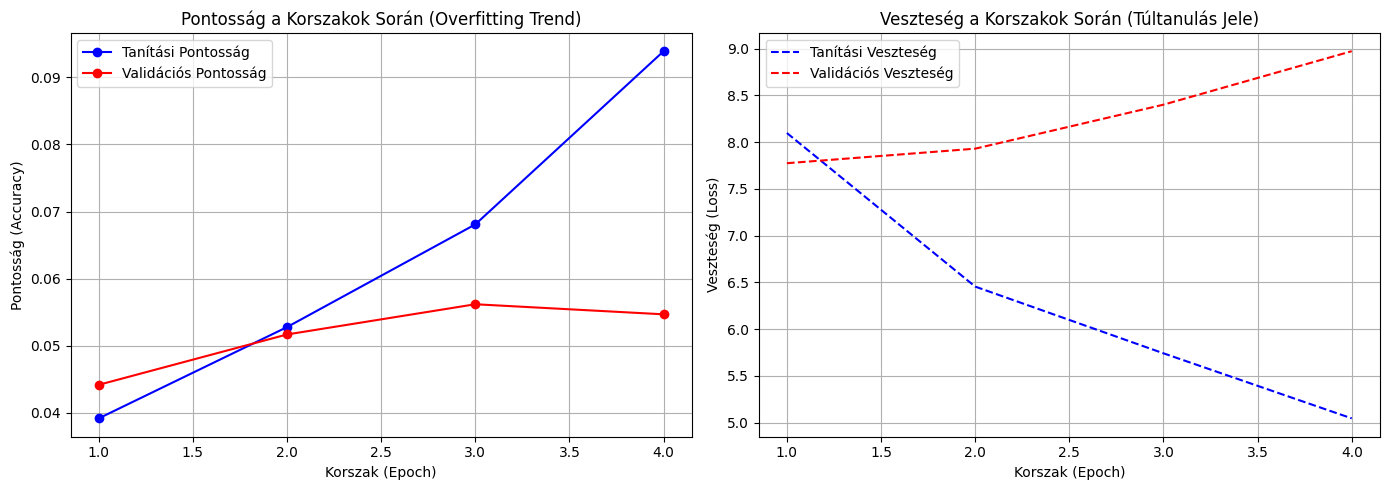


--- A Grafikonok Elemzése ---
Tanítási Pontosság (Utolsó): 9.39%
Validációs Pontosság (Utolsó): 5.47%

EREDMÉNY: SÚLYOS TÚLTANULÁS (OVERFITTING) TÖRTÉNT.
A Validációs Veszteség folyamatosan NÖVEKSZIK, miközben a Tanítási Veszteség csökken.
EZ IGAZOLJA A KORÁBBI VÁLTÁST: TÚL SOKÁIG TARTOTT AZ EPOCH.


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --- Adatok kinyerése a beszélgetési logból (KÉZI BEÉPÍTÉS) ---

# Pontosság (Accuracy)
train_acc = [0.0392, 0.0528, 0.0681, 0.0939]
val_acc = [0.0442, 0.0517, 0.0562, 0.0547]

# Veszteség (Loss)
train_loss = [8.0982, 6.4558, 5.7423, 5.0467]
val_loss = [7.7751, 7.9307, 8.4011, 8.9730]

epochs = range(1, len(train_acc) + 1)

# -------------------- Két Grafikon Rajzolása --------------------

plt.figure(figsize=(14, 5))

# --- 1. Pontosság Grafikon ---
plt.subplot(1, 2, 1) # Egy sor, két oszlop, első ábra
plt.plot(epochs, train_acc, 'bo-', label='Tanítási Pontosság')
plt.plot(epochs, val_acc, 'ro-', label='Validációs Pontosság')
plt.title('Pontosság a Korszakok Során (Overfitting Trend)')
plt.xlabel('Korszak (Epoch)')
plt.ylabel('Pontosság (Accuracy)')
plt.legend()
plt.grid(True)

# --- 2. Veszteség Grafikon ---
plt.subplot(1, 2, 2) # Egy sor, két oszlop, második ábra
plt.plot(epochs, train_loss, 'b--', label='Tanítási Veszteség')
plt.plot(epochs, val_loss, 'r--', label='Validációs Veszteség')
plt.title('Veszteség a Korszakok Során (Túltanulás Jele)')
plt.xlabel('Korszak (Epoch)')
plt.ylabel('Veszteség (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Két grafikon illesztése
plt.show()

# -------------------- Eredmények Értékelése (Következtetés) --------------------

print("\n--- A Grafikonok Elemzése ---")
print(f"Tanítási Pontosság (Utolsó): {train_acc[-1]*100:.2f}%")
print(f"Validációs Pontosság (Utolsó): {val_acc[-1]*100:.2f}%")

if val_loss[-1] > val_loss[0] * 1.1:
    print("\nEREDMÉNY: SÚLYOS TÚLTANULÁS (OVERFITTING) TÖRTÉNT.")
    print("A Validációs Veszteség folyamatosan NÖVEKSZIK, miközben a Tanítási Veszteség csökken.")
    print("EZ IGAZOLJA A KORÁBBI VÁLTÁST: TÚL SOKÁIG TARTOTT AZ EPOCH.")

**Miért lehet ez?** : A MobilNetV2 egy önálló, rengeteg layerből álló komplex architektúra, ami nem erre az adatbázisra tanult be, hanem jól betanult egy másikra. A klasszifikációs fej persze az 5749 osztályhoz igazítja, de a backbone-ját úgy hagytuk, ez túl specifikus.

Tesztelést is végezzünk, gyenge pontosságot várva:
Kiveszi a legjobb model mappájában lévő modellt, betölti a súlyait, majd végigszámolja a teszteredményt.

In [28]:
#------------------------------v0: TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.0434 - loss: 7.9364

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.9228
Teszt Pontosság (Test Accuracy): 4.42%


Eredmény: 4,42 %-os pontosság. Ezzel nem elégszünk meg, így hát szükségünk lesz finomhangolásra.

# 5. Háló architektúra módosítása, hiperparaméter optimalizálás

A kiértékelés során arra jutottunk, hogy a modell nem elég pontos. Így tehát szükségünk van finomhangolásra. Ennek lényege, hogy az eddigi modellen kicsiket változtatgatunk, hiszen már az alapja megvan, és addig optimalizálunk, míg kívánt modellt nem kapunk.
Több paraméter is állítható, nézzük meg, mi történik az egyes paraméterekre való finomhangolás során:


1.   **Epoch-ok száma**
2.   **Patience értéke**
3.   **Képfelbontás**
4.   **Befagyasztott Layer-ek száma**
5.   **Augmentáció **

Nézzük ezeket sorra:

1.   **Epoch-ok száma**: A konkrét változón változtatás nem sokat számítana, hiszen ahogyan v0-nál is, később is látszik, hogy bőven nem fut végig a 30 epoch, hamarabb megáll EarlyStopping-gal, vagy manuálisan általam, mert nem fejlődik.

2.   **Patience értéke**: Ez csak az EarlyStopping bekövetkeztét konrtollálja, ha magasabbnak választjuk, passzívabb, ha nagyon kicsire, akkor agresszívan reagáló modellt kapunk. (patience=0 esetén nem engedné a romlást egyáltalán)

3.   **Képfelbontás**: Alapvetően minél kevesebb pixelből áll a kép, annál pontatlanabb lesz a model. Cserébe kevesebb pixelen átszámolnia magát a hálónak minden egyes epochban sokat javít a tanulás idején. Igazából ezt sem érdemes módosítani, hiszen maximum 250-ig növelhetnénk, ami nem olyan sok változás a 224-hez képest (12324 pixel/kép), persze kicsit lehet javítana a modellen, ugyanakkor a MobilNetV2 alapbeállításáról elállítanánk.

4.   **Befagyasztott Layer-ek száma**: Főként ez ami módosítható. Az első 100 rétege a MobilNetV2-nek nagyon generikus jellemzőket tanulnak, így azokat meghagyjuk fagyasztva. A többi 55 réteg közül van opciónk kifagyasztani valamennyit. (Meg persze a klasszifikáló fej a végén).

5.   **Augmentáció **: Ennek célja a háló robosztussá tétele, ezáltal védelem a túltanulás ellen. Felkészítjük vele a hálót arra, hogy jobban kompenzálja a zajhatásokat. A jelen esetben ezt megoldhatjuk például egy random kontraszt, random horizontális tükrözés és random elforgatás beállításával.

## Az 5 verzió a szabadon hagyott layerek módosításával

In [41]:
import pandas as pd

datacska = {
    # Első Oszlop
    'Finomhangolás szintje': [
        'Magas',
        'Közepes',
        'Alacsony'
    ],

    # Második Oszlop
    'Szabad layerek száma': [
        '10-15',
        '30-50',
        '70-80'

    ],

    # Harmadik Oszlop
    'várható pontosság [%]': [
        '10-15',
        '30-50',
        '0-5'

    ]
}

# -------------------------------------------------------------
# 2. Pandas DataFrame (Táblázat) Létrehozása
# -------------------------------------------------------------

df = pd.DataFrame(datacska)

# -------------------------------------------------------------
# 3. Táblázat Megjelenítése
# -------------------------------------------------------------

print("--- A szabadon hagyott layerek számának hatása a pontosságra ---")
print(df)

--- A szabadon hagyott layerek számának hatása a pontosságra ---
  Finomhangolás szintje Szabad layerek száma várható pontosság [%]
0                 Magas                10-15                 10-15
1               Közepes                30-50                 30-50
2              Alacsony                70-80                   0-5


Ezek alapján:

*   **Magas szinten:** A bázis kicsit túl meghatározó, de egész jó eredémyt érhetünk el, bár van jobb.
*   **Közepes szinten:** Arany zóna, ez a középút, itt várhatunk maximumot.
*   **Alacsony szinten:** Túl nagy szabadságot kap a háló, és hajlamos elfelejteni a jellemzőket.

Mivel CNN-ről van szó, ahol a tanulási idők rendkívül magasak a nagy adathalmaz miatt, a közepes hangolási szint helyett inkább az alacsony szinten próbáltam optimalizálni. A vizsgált verziók(szabad layerek számával) sorban: 15, 10, 5, 2, 1

###V1

In [42]:
#-------------V1: A 15 layeres verzio -------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Alapmodell létrehozása (MobileNetV2)
# -------------------------------------------------------------

normalization_layer = Rescaling(1./255)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FINOMHANGOLÁS: A teljes backbone tanítható
base_model.trainable = True

# 3. A korai (generikus) rétegek fagyasztása (USER MODIFIED)
FINE_TUNE_AT = 140 #marad még  kb 15 layer opcionalisan

for layer in base_model.layers[:FINE_TUNE_AT]: #azutan kifagyaszt
    layer.trainable = False

# -------------------------------------------------------------
# 4. Modell Láncolása (Custom Head + Regularizáció)
# -------------------------------------------------------------

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = normalization_layer(inputs)
x = base_model(x, training=True) # training=True, mert finomhangolunk
x = GlobalAveragePooling2D()(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 5. Fordítás: Learning Rate Korrekció (0.0001)
# -------------------------------------------------------------
model.compile(
  optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 4,645,109 (17.72 MB)

 Non-trainable params: 1,217,984 (4.65 MB)

In [ ]:
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0313 - loss: 8.3070
Epoch 1: val_loss improved from inf to 9.53032, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 1736s 5s/step - accuracy: 0.0313 - loss: 8.3062 - val_accuracy: 0.0423 - val_loss: 9.5303
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0630 - loss: 7.1838
Epoch 2: val_loss improved from 9.53032 to 8.41048, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.0630 - loss: 7.1839 - val_accuracy: 0.0589 - val_loss: 8.4105
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0901 - loss: 6.7070
Epoch 3: val_loss did not improve from 8.41048
331/331 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.0901 - loss: 6.7071 - val_accuracy: 0.0619 - val_loss: 8.5968
Epoch 4/30
331/33

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Adatok kinyerése a beszélgetési logból (1-10. KORSZAK) ---
# A 15 tanítható réteggel és Augmentációval indított kísérlet logja alapján.

# Pontosság (Accuracy)
train_acc = [0.0313, 0.0630, 0.0901, 0.1093, 0.1320, 0.1552, 0.1769, 0.2087, 0.2547, 0.3070]
val_acc = [0.0423, 0.0589, 0.0619, 0.0831, 0.0982, 0.1163, 0.1375, 0.1405, 0.1511, 0.1450]

# Veszteség (Loss)
train_loss = [8.3062, 7.1839, 6.7071, 6.2898, 5.9118, 5.5207, 5.1471, 4.7266, 4.2657, 3.7621]
val_loss = [9.5303, 8.4105, 8.5968, 8.0124, 7.9179, 7.6143, 7.5277, 7.5590, 7.7708, 7.9047]

epochs = range(1, len(train_acc) + 1)

# -------------------- Két Grafikon Rajzolása --------------------

plt.figure(figsize=(14, 5))

# --- 1. Pontosság Grafikon ---
plt.subplot(1, 2, 1) # Egy sor, két oszlop, első ábra
plt.plot(epochs, train_acc, 'bo-', label='Tanítási Pontosság')
plt.plot(epochs, val_acc, 'ro-', label='Validációs Pontosság')
plt.title('Pontosság a Korszakok Során (1-10. Epoch)')
plt.xlabel('Korszak (Epoch)')
plt.ylabel('Pontosság (Accuracy)')
plt.legend()
plt.grid(True)

# --- 2. Veszteség Grafikon ---
plt.subplot(1, 2, 2) # Egy sor, két oszlop, második ábra
plt.plot(epochs, train_loss, 'b--', label='Tanítási Veszteség')
plt.plot(epochs, val_loss, 'r--', label='Validációs Veszteség')
plt.title('Veszteség a Korszakok Során (1-10. Epoch)')
plt.xlabel('Korszak (Epoch)')
plt.ylabel('Veszteség (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Két grafikon illesztése
plt.show()

# -------------------- Eredmények Értékelése --------------------

min_val_loss = min(val_loss)
min_loss_index = val_loss.index(min_val_loss) + 1

print("\n--- A Grafikonok Elemzése ---")
print(f"Tanítási Pontosság (Utolsó): {train_acc[-1]*100:.2f}%")
print(f"Validációs Pontosság (Utolsó): {val_acc[-1]*100:.2f}%")
print(f"Optimális korszak (Legalacsonyabb val_loss): {min_loss_index}. korszak ({min_val_loss:.4f})")

In [ ]:
#------------------------------v1: TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.1485 - loss: 7.3324

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.3093
Teszt Pontosság (Test Accuracy): 14.73%


###V2

In [ ]:
#2. verzió: 10 layeres
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Alapmodell létrehozása (MobileNetV2)
# -------------------------------------------------------------

normalization_layer = Rescaling(1./255)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FINOMHANGOLÁS: A teljes backbone tanítható
base_model.trainable = True

# 3. A korai (generikus) rétegek fagyasztása (USER MODIFIED)
FINE_TUNE_AT = 145 #marad még  kb 10 layer opcionalisan

for layer in base_model.layers[:FINE_TUNE_AT]: #azutan kifagyaszt
    layer.trainable = False

# -------------------------------------------------------------
# 4. Modell Láncolása (Custom Head + Regularizáció)
# -------------------------------------------------------------

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = normalization_layer(inputs)
x = base_model(x, training=True) # training=True, mert finomhangolunk
x = GlobalAveragePooling2D()(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 5. Fordítás: Learning Rate Korrekció (0.0001)
# -------------------------------------------------------------
model.compile(
  optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 4,335,669 (16.54 MB)

 Non-trainable params: 1,527,424 (5.83 MB)

In [ ]:
#----------------------V2 TANÍTÁS -----------------------------
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0334 - loss: 8.3298
Epoch 1: val_loss improved from inf to 14.19388, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 2237s 7s/step - accuracy: 0.0334 - loss: 8.3291 - val_accuracy: 0.0405 - val_loss: 14.1939
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.0551 - loss: 7.2036
Epoch 2: val_loss improved from 14.19388 to 9.60519, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 48s 145ms/step - accuracy: 0.0552 - loss: 7.2038 - val_accuracy: 0.0450 - val_loss: 9.6052
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.0710 - loss: 6.7868
Epoch 3: val_loss improved from 9.60519 to 8.66617, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━

In [ ]:
#------------------------------V2 TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 228s 5s/step - accuracy: 0.0871 - loss: 8.2013

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 8.1750
Teszt Pontosság (Test Accuracy): 8.61%


###V3

In [ ]:
#3. verzió: 5 layeres
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Alapmodell létrehozása (MobileNetV2)
# -------------------------------------------------------------

normalization_layer = Rescaling(1./255)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FINOMHANGOLÁS: A teljes backbone tanítható
base_model.trainable = True

# 3. A korai (generikus) rétegek fagyasztása (USER MODIFIED)
FINE_TUNE_AT = 150 #marad még  kb 5 layer opcionalisan

for layer in base_model.layers[:FINE_TUNE_AT]: #azutan kifagyaszt
    layer.trainable = False

# -------------------------------------------------------------
# 4. Modell Láncolása (Custom Head + Regularizáció)
# -------------------------------------------------------------

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = normalization_layer(inputs)
x = base_model(x, training=True) # training=True, mert finomhangolunk
x = GlobalAveragePooling2D()(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 5. Fordítás: Learning Rate Korrekció (0.0001)
# -------------------------------------------------------------
model.compile(
  optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 4,017,909 (15.33 MB)

 Non-trainable params: 1,845,184 (7.04 MB)

In [ ]:
#----------------------V3 TANÍTÁS -----------------------------
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0359 - loss: 8.2445
Epoch 1: val_loss improved from inf to 7.95166, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 1957s 6s/step - accuracy: 0.0359 - loss: 8.2440 - val_accuracy: 0.0367 - val_loss: 7.9517
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0540 - loss: 7.1425
Epoch 2: val_loss improved from 7.95166 to 7.76392, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 52s 155ms/step - accuracy: 0.0540 - loss: 7.1429 - val_accuracy: 0.0472 - val_loss: 7.7639
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.0679 - loss: 6.7436
Epoch 3: val_loss improved from 7.76392 to 7.66457, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━

In [ ]:
#------------------------------V3  TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.0675 - loss: 7.7760

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.7980
Teszt Pontosság (Test Accuracy): 6.40%


###V4

In [ ]:
#4. verzió: 2 layeres
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Alapmodell létrehozása (MobileNetV2)
# -------------------------------------------------------------

normalization_layer = Rescaling(1./255)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FINOMHANGOLÁS: A teljes backbone tanítható
base_model.trainable = True

# 3. A korai (generikus) rétegek fagyasztása (USER MODIFIED)
FINE_TUNE_AT = 153 #marad még  kb 2 layer opcionalisan

for layer in base_model.layers[:FINE_TUNE_AT]: #azutan kifagyaszt
    layer.trainable = False

# -------------------------------------------------------------
# 4. Modell Láncolása (Custom Head + Regularizáció)
# -------------------------------------------------------------

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = normalization_layer(inputs)
x = base_model(x, training=True) # training=True, mert finomhangolunk
x = GlobalAveragePooling2D()(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 5. Fordítás: Learning Rate Korrekció (0.0001)
# -------------------------------------------------------------
model.compile(
  optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 3,605,109 (13.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#----------------------V4 TANÍTÁS -----------------------------
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0294 - loss: 8.3572
Epoch 1: val_loss did not improve from 7.66457
331/331 ━━━━━━━━━━━━━━━━━━━━ 68s 176ms/step - accuracy: 0.0295 - loss: 8.3566 - val_accuracy: 0.0352 - val_loss: 7.9925
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.0438 - loss: 7.3583
Epoch 2: val_loss did not improve from 7.66457
331/331 ━━━━━━━━━━━━━━━━━━━━ 48s 146ms/step - accuracy: 0.0439 - loss: 7.3586 - val_accuracy: 0.0435 - val_loss: 7.8685
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.0508 - loss: 7.0301
Epoch 3: val_loss did not improve from 7.66457
331/331 ━━━━━━━━━━━━━━━━━━━━ 46s 139ms/step - accuracy: 0.0508 - loss: 7.0304 - val_accuracy: 0.0465 - val_loss: 7.8467
Epoch 4/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.0560 - loss: 6.7852
Epoch 4: val_loss did not improve from 7.66457
331/331 ━━━━━━━━━━━━━━━━━━━━ 48s 146ms/step - accuracy: 0.0560 - los

In [ ]:
#------------------------------V4  TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
 1/41 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.0938 - loss: 8.1295

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.0686 - loss: 7.8100

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.7481
Teszt Pontosság (Test Accuracy): 6.33%


###V5

In [33]:
#5. verzió: 1 layeres
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Alapmodell létrehozása (MobileNetV2)
# -------------------------------------------------------------

normalization_layer = Rescaling(1./255)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. FINOMHANGOLÁS: A teljes backbone tanítható
base_model.trainable = True

# 3. A korai (generikus) rétegek fagyasztása (USER MODIFIED)
FINE_TUNE_AT = 154 #marad még  kb 1 layer opcionalisan

for layer in base_model.layers[:FINE_TUNE_AT]: #azutan kifagyaszt
    layer.trainable = False

# -------------------------------------------------------------
# 4. Modell Láncolása (Custom Head + Regularizáció)
# -------------------------------------------------------------

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = normalization_layer(inputs)
x = base_model(x, training=True) # training=True, mert finomhangolunk
x = GlobalAveragePooling2D()(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)

# Regularizáció a túltanulás ellen
x = Dropout(0.4)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 5. Fordítás: Learning Rate Korrekció (0.0001)
# -------------------------------------------------------------
model.compile(
  optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 3,605,109 (13.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
#----------------------V5 TANÍTÁS -----------------------------
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0317 - loss: 8.3457
Epoch 1: val_loss improved from inf to 7.95856, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accuracy: 0.0317 - loss: 8.3451 - val_accuracy: 0.0405 - val_loss: 7.9586
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0428 - loss: 7.3698
Epoch 2: val_loss improved from 7.95856 to 7.85529, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.0428 - loss: 7.3701 - val_accuracy: 0.0450 - val_loss: 7.8553
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0481 - loss: 7.0398
Epoch 3: val_loss improved from 7.85529 to 7.78979, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 534s 

KeyboardInterrupt: 

In [35]:
#------------------------------V5  TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.0452 - loss: 7.9312

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.8806
Teszt Pontosság (Test Accuracy): 5.18%


# Az augmentáció hatása

Vizsgáljunk meg az egyik verzió augmentált változatát:

In [53]:
# -----------------V0, augmentált ------------------------

from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomContrast # Augmentáció importálva


# ----------------- 1. Adat-Augmentációs Réteg Létrehozása -----------------
data_augmentation = keras.Sequential(
  [
    RandomFlip("horizontal"), # Vízszintes tükrözés (arcoknál természetes)
    RandomRotation(0.05),  # Enyhe, 5%-os elforgatás
    RandomContrast(0.2)  # Kontraszt finomhangolása
  ],
  name="data_augmentation_layer" # Adunk neki egy nevet
)
# -------------------------------------------------------------------------

# -------------------------------------------------------------
# 2. Alapmodell és Normalizáló Réteg Létrehozása
# -------------------------------------------------------------



# Új Normalizáló Réteg a háló bemenetére
normalization_layer = Rescaling(1./255)

# A MobileNetV2 alapmodell
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Fagyasztás teljesen

# -------------------------------------------------------------
# 3. Modell Láncolása (Sequential/Functional API)
# -------------------------------------------------------------

# Létrehozzuk a teljes modellt, ahol a Rescaling a legelső lépés:
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)) # Bemenet 224x224 ra beallitva

# 1. Lépés: Normalizálás 0-1 tartományba
x = normalization_layer(inputs)

# 2. Lépés: Átadjuk az adatot a fagyasztott MobileNetV2-nek
x = base_model(x, training=False)

# 3. Lépés: A saját osztályozó fejünk (Pooling, Dense, kimenet)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# A teljes modell létrehozása
model = Model(inputs=inputs, outputs=predictions)

# -------------------------------------------------------------
# 3. Fordítás (Compilation)
# -------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5749)           │     2,949,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863,093 (22.37 MB)

 Trainable params: 3,605,109 (13.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
#----------------------V0, augmentált TANÍTÁS -----------------------------
print("A háló tanítása megkezdődött...")

# A history változóban tároljuk a tanítási metrikákat (veszteség, pontosság)
history = model.fit(
    train_ds,             # Tanító adathalmaz
    epochs=EPOCHS,        # Maximális korszak szám
    validation_data=validation_ds, # Validációs adathalmaz
    callbacks=callbacks_list      # Védelmi funkciók aktiválása
)

print("\nHáló tanítása befejeződött.")
print(f"A legjobb modell a '{checkpoint_filepath}' útvonalra lett mentve.")

A háló tanítása megkezdődött...
Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0395 - loss: 8.1006
Epoch 1: val_loss improved from inf to 7.79597, saving model to drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - accuracy: 0.0395 - loss: 8.1001 - val_accuracy: 0.0390 - val_loss: 7.7960
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0590 - loss: 6.3318
Epoch 2: val_loss did not improve from 7.79597
331/331 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.0590 - loss: 6.3323 - val_accuracy: 0.0480 - val_loss: 7.8579
Epoch 3/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0787 - loss: 5.6634
Epoch 3: val_loss did not improve from 7.79597
331/331 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.0787 - loss: 5.6638 - val_accuracy: 0.0502 - val_loss: 8.4161
Epoch 4/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1038 - loss: 4.9556
Epoch 4: val_loss did not improve f

KeyboardInterrupt: 

In [55]:
#------------------------------V0, augmentalt TESZTELÉS-------------------------------
import os
import tensorflow as tf
from tensorflow.keras.models import Model # Szükséges a modell struktúrájához

# ----------------- Drive Elérési Utak (Győződj meg róla, hogy helyesek) -----------------
# Ezeket az útvonalakat az előző lépésekben állítottuk be.
BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"

# A teljes útvonal a legjobb súlyokhoz a Drive-on
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')


print("--- Teszt készlet értékelése ---")

try:
    # 1. Betöltjük a legjobb súlyokat a Drive-ról a memóriában lévő modell struktúrára
    # A 'model' objektumot feltételezzük, hogy még létezik a Colab memóriájában
    model.load_weights(checkpoint_filepath)
    print(f"Súlyok sikeresen betöltve a Drive-ról: {checkpoint_filepath}")

    # 2. Értékeljük a betöltött, legjobb modellt a Teszt készleten
    test_results = model.evaluate(test_ds, verbose=1)

    print("\n--- VÉGLEGES EREDMÉNYEK ---")
    print(f"Teszt Veszteség (Test Loss): {test_results[0]:.4f}")
    print(f"Teszt Pontosság (Test Accuracy): {test_results[1]*100:.2f}%")

except FileNotFoundError:
    print(f"\nHIBA: A mentett modell fájl nem található a következő útvonalon: {checkpoint_filepath}")
    print("Kérlek, ellenőrizd, hogy a tanítás (4. lépés) legalább 1 korszakot futott-e, és sikeresen mentette-e a fájlt a Google Drive-ra!")
except NameError:
    print("\nHIBA: A 'model' objektum nem található a memóriában. Kérlek, futtasd le a Modell Láncolása (3. lépés) kódot újra a tesztelés előtt!")

--- Teszt készlet értékelése ---
Súlyok sikeresen betöltve a Drive-ról: drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model/best_lfw_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.0405 - loss: 7.9896

--- VÉGLEGES EREDMÉNYEK ---
Teszt Veszteség (Test Loss): 7.8785
Teszt Pontosság (Test Accuracy): 4.80%


**Eredmény**: A sima v0 4,4% os eredményt hozott, az augmentált változata ettől 0,4%-kal jobbat!

# 6. Végső eredmények

In [101]:
import pandas as pd

datacska = {
    # Első Oszlop
    'Verzió': [
        'v0',
        'v1',
        'v2',
        'v3',
        'v4',
        'v5'
    ],

    # Második Oszlop
    'Szabad layerek száma': [
        '0',
        '15',
        '10',
        '5',
        '2',
        '1'

    ],

    # Harmadik Oszlop
    'pontosság [%]': [
        '4,42',
        '14,73',
        '8,61',
        '6,4',
        '6,33',
        '5,18'

    ],
    # Negyedik oszlop
    'Véletlenszerű tipp hányszorosa': [
        '254',
        '846',
        '494',
        '367',
        '362',
        '297'

    ]
}

# -------------------------------------------------------------
# 2. Pandas DataFrame (Táblázat) Létrehozása
# -------------------------------------------------------------

df = pd.DataFrame(datacska)

# -------------------------------------------------------------
# 3. Táblázat Megjelenítése
# -------------------------------------------------------------

print("--- A szabadon hagyott layerek számának hatása a pontosságra ---")
print(df)

--- A szabadon hagyott layerek számának hatása a pontosságra ---
  Verzió Szabad layerek száma pontosság [%] Véletlenszerű tipp hányszorosa
0     v0                    0          4,42                            254
1     v1                   15         14,73                            846
2     v2                   10          8,61                            494
3     v3                    5           6,4                            367
4     v4                    2          6,33                            362
5     v5                    1          5,18                            297


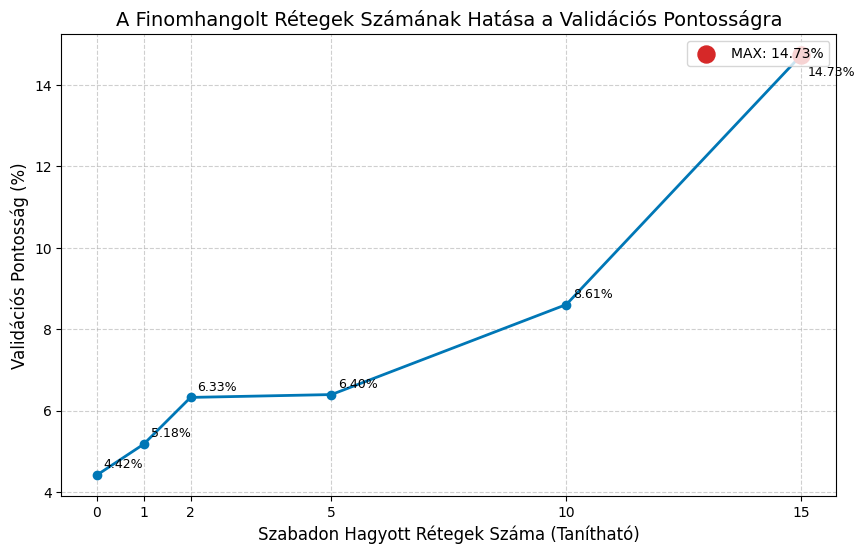


--- A Legjobb Pontosság Eredménye ---
A legjobb pontosságot 15 tanítható réteggel érte el a rendszer: 14.73%


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# A felhasználó által megadott adatok a rétegszám és pontosság összehasonlítására
szabad_layerek = [0, 15, 10, 5, 2, 1]
pontossag = [4.42, 14.73, 8.61, 6.40, 6.33, 5.18]
verzioszamok = ['v0 (0)', 'v1 (15)', 'v2 (10)', 'v3 (5)', 'v4 (2)', 'v5 (1)']

# Adatok rendezése a vizuális ábrázolás megkönnyítésére (X tengely, azaz szabad rétegek száma szerint)
# Ez biztosítja, hogy a vonal a rétegszám növekedésének/csökkenésének megfelelően haladjon
data = sorted(zip(szabad_layerek, pontossag, verzioszamok))
szabad_layerek_sorted, pontossag_sorted, verzioszamok_sorted = zip(*data)

# -------------------- Grafikon Rajzolása --------------------
plt.figure(figsize=(10, 6))

# Vonaldiagram a trendek és a nem-lineáris viselkedés hangsúlyozására
plt.plot(szabad_layerek_sorted, pontossag_sorted, marker='o', linestyle='-', color='#0077B6', linewidth=2)

# Minden pont mellé felírjuk a pontosságot és a verziószámot
for i, txt in enumerate(verzioszamok_sorted):
    # A szöveg elhelyezése, hogy ne fedje el a vonalat (az X tengelyen lévő pontokhoz igazítva)
    plt.annotate(f"{pontossag_sorted[i]:.2f}%",
                 (szabad_layerek_sorted[i], pontossag_sorted[i]),
                 textcoords="offset points",
                 xytext=(5, -15 if szabad_layerek_sorted[i] == 15 else 5), # Kiemeljük a 15-ös pontot
                 ha='left',
                 fontsize=9)
    # Külön címke a verziószámoknak
    #plt.annotate(f"{txt}",
             #    (szabad_layerek_sorted[i], pontossag_sorted[i]),
                # textcoords="offset points",
               #  xytext=(5, 5),
               #  ha='left',
               #  fontsize=10,
                # fontweight='bold')

# Grafikon beállítások
plt.title('A Finomhangolt Rétegek Számának Hatása a Validációs Pontosságra', fontsize=14)
plt.xlabel('Szabadon Hagyott Rétegek Száma (Tanítható)', fontsize=12)
plt.ylabel('Validációs Pontosság (%)', fontsize=12)
# Az X tengelyen csak a kísérleti értékek jelenjenek meg
plt.xticks(szabad_layerek_sorted, labels=[f'{l}' for l in szabad_layerek_sorted])
plt.grid(True, linestyle='--', alpha=0.6)

# A legjobb eredmény kiemelése (Piros pont)
max_acc = max(pontossag)
max_idx = pontossag.index(max_acc)
plt.scatter(szabad_layerek[max_idx], pontossag[max_idx], color='#D62828', s=150, zorder=5, label=f'MAX: {max_acc:.2f}%')

plt.legend(loc='upper right')
plt.show()

print("\n--- A Legjobb Pontosság Eredménye ---")
print(f"A legjobb pontosságot {szabad_layerek[max_idx]} tanítható réteggel érte el a rendszer: {max_acc:.2f}%")

# Továbbfejlesztési lehetőségek:


*   **Rétegzett mintavétel:** Mivel kiegyensúlyozatlan az osztályok eloszlása a szétválasztott training/validation/test adatok közt, kioszthatnánk ezeknek arányosan. Például: Pistiről van 10 kép, akkor 8 megy trainingnek, és 1-1 validációs és teszt
*   **Személyek előszűrése:** Az adathalmaz feltértképezése során már megfigyeltük, hogy nagy a képek számának szórása osztályonként. Valakiről van 15, sokakról meg csak 1. Az előszűréssel ez a torzulás megoldódik, ha eldobjuk azokat a személyeket, akik mondjuk 5 képnél kevesebbel rendelkeznek.



#7. Demonstrációs script

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ----------------- KÉP FELDOLGOZÁS ÉS PREDIKCIÓS FÜGGVÉNY -----------------

# Feltételezzük, hogy az 'class_names' (osztálynevek) változó definiálva van a Notebookodban!

def visualize_prediction(model, image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    """
    Vizualizálja a bemeneti képet, a valós osztályt és a modell TOP 5 predikcióját.
    """
    try:
        # 1. Kép Előkészítése (Azonos Előkészítés, mint a tréningnél)
        img = load_img(image_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)  # Batch dimenzió hozzáadása

        # Ne feledd a normalizálást, ha a modell feje tartalmazza:
        # Ha a normalizálás a háló része (Rescaling(1./255)), akkor itt már nem kell!

        # 2. Predikció Lekérése
        # A predikció egy valószínűségi vektor (NUM_CLASSES hosszú)
        predictions = model.predict(img_array)
        scores = predictions[0] # Csak a batch első elemének eredménye

        # 3. TOP 5 Predikció Keresése
        # A 5 legnagyobb valószínűségű osztály indexét keressük
        top_5_indices = np.argsort(scores)[::-1][:5]
        top_5_probabilities = scores[top_5_indices]
        top_5_classes = [class_names[i] for i in top_5_indices]

        # 4. Vizualizáció

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # --- Bal: Kép Megjelenítése ---
        axes[0].imshow(img)
        axes[0].set_title(f"Vizsgált Kép", fontsize=14)
        axes[0].axis('off')

        # --- Jobb: Predikciók Listázása ---

        # Keresd meg a valós (Ground Truth) nevet! Ehhez az image_path-ból kellene kinyerni.
        # Feltételezzük, hogy a kép neve tartalmazza a személy nevét!
        file_name = os.path.basename(image_path)

        # Egy gyors, de nem robusztus módszer a Ground Truth-ra (személy neve)
        try:
            ground_truth_name = file_name.split('_')[0]
        except:
            ground_truth_name = "Ismeretlen/Kézi Ellenőrzés Szükséges"


        axes[1].barh(top_5_classes, top_5_probabilities, color='skyblue')
        axes[1].set_xlabel("Valószínűség")
        axes[1].set_title(f"Valós (Ground Truth): {ground_truth_name}\nTOP 5 Predikció", fontsize=14)
        axes[1].invert_yaxis() # A legmagasabb valószínűség legyen felül

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Hiba történt a predikció során: {e}")

# Megjegyzés: Szükség van az 'os' importra is, ha a 'file_name' kinyerést használod!
import os

In [61]:
# ----------------- MODELL BETÖLTÉSE (Ellenőrzés) -----------------
# Kérlek, ellenőrizd, hogy az útvonalak és a 'model' struktúra létezik-e!

BEST_MODEL_DRIVE_DIR = "drive/MyDrive/colab_notebooks/Python_mernoki_alk/best_model"
checkpoint_filepath = os.path.join(BEST_MODEL_DRIVE_DIR, 'best_lfw_model.keras')

try:
    # A modell struktúra már a memóriában van (3. lépés), csak a súlyokat töltjük
    model.load_weights(checkpoint_filepath)
    print("Súlyok sikeresen betöltve a Drive-ról. Készen áll a tesztelésre!")
except Exception as e:
    print(f"Hiba a súlyok betöltésekor: {e}")
    print("HIBA: Kérlek, futtasd le a 3. lépés (Modell Láncolása) kódját!")

Súlyok sikeresen betöltve a Drive-ról. Készen áll a tesztelésre!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


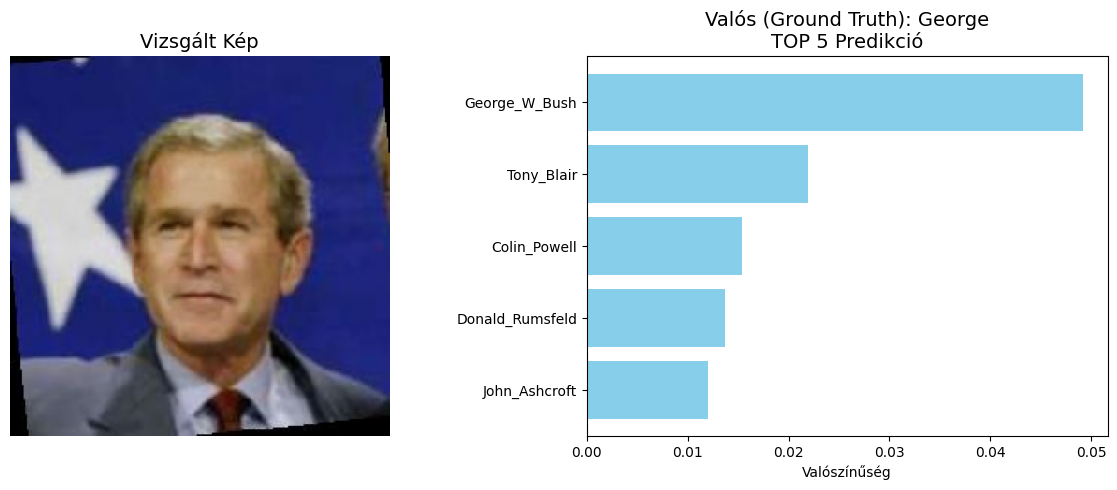

In [104]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/George_W_Bush/George_W_Bush_0001.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


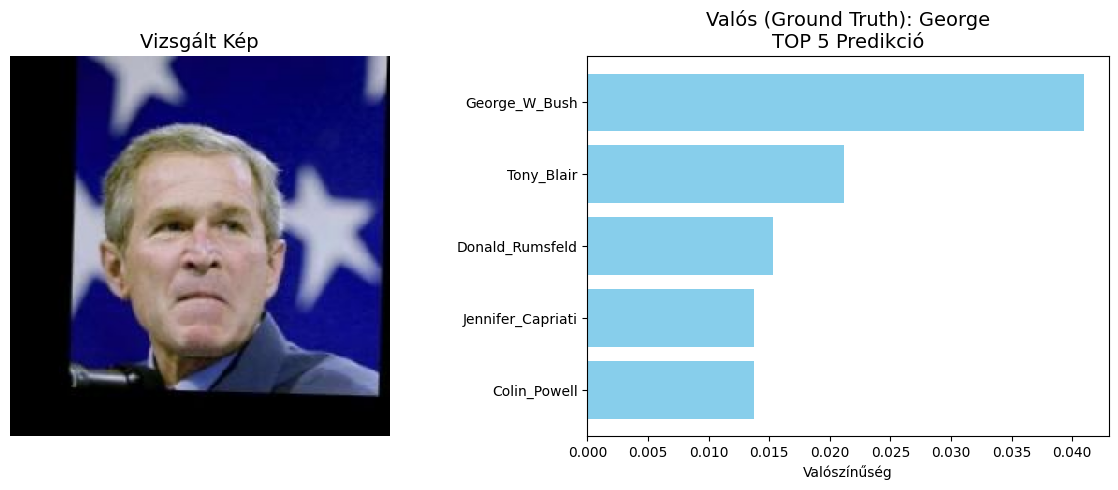

In [105]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/George_W_Bush/George_W_Bush_0002.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


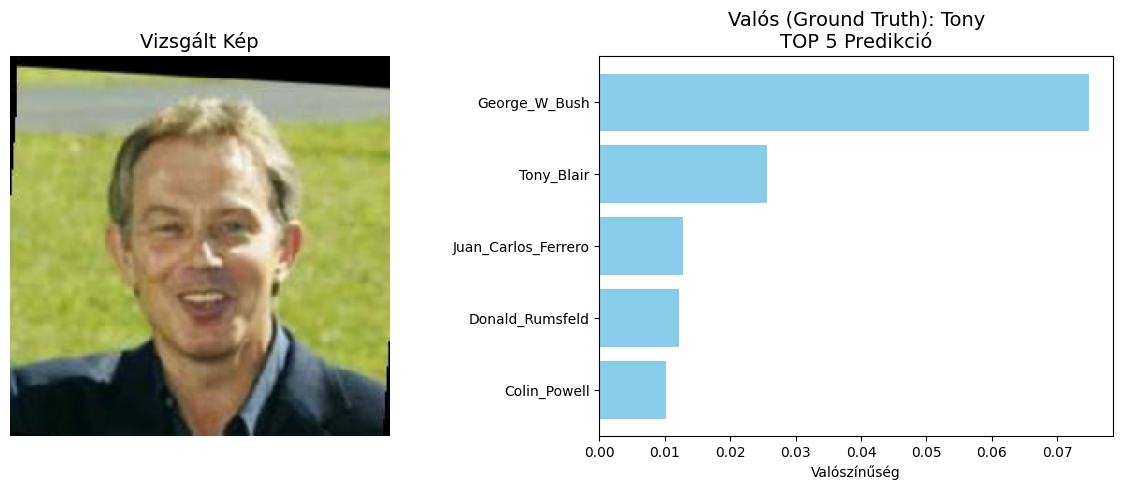

In [106]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Tony_Blair/Tony_Blair_0002.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

In [ ]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Tony_Blair/Tony_Blair_0001.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


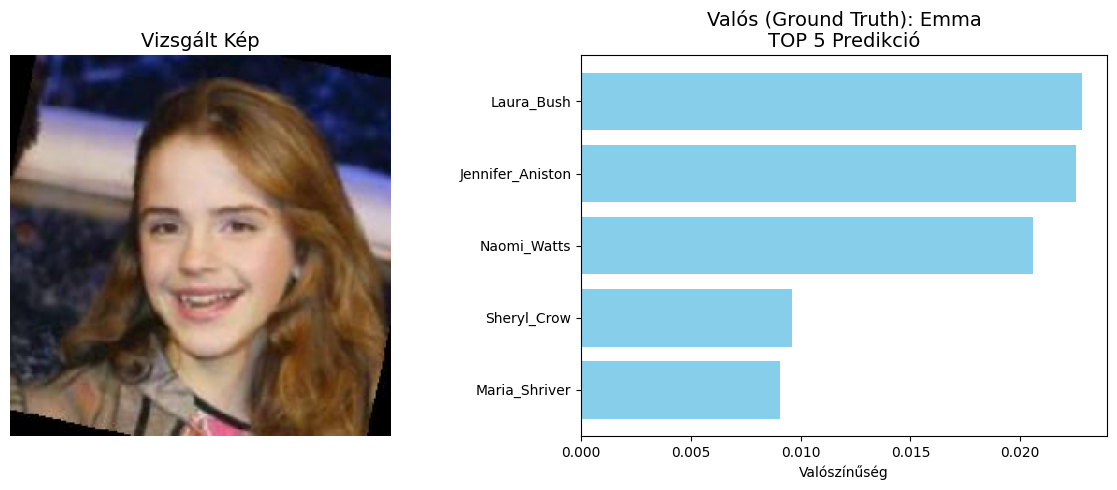

In [107]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Emma_Watson/Emma_Watson_0005.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


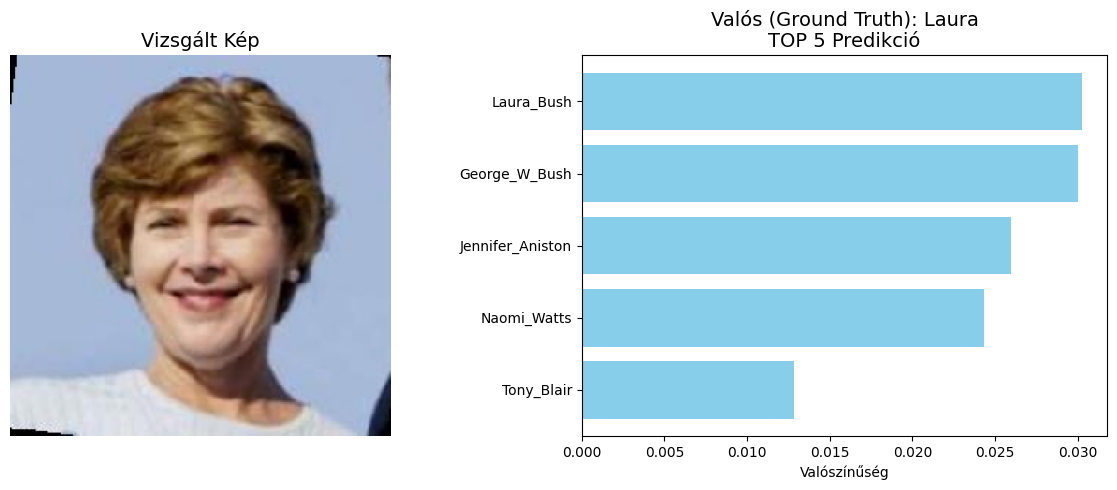

In [108]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Laura_Bush/Laura_Bush_0001.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


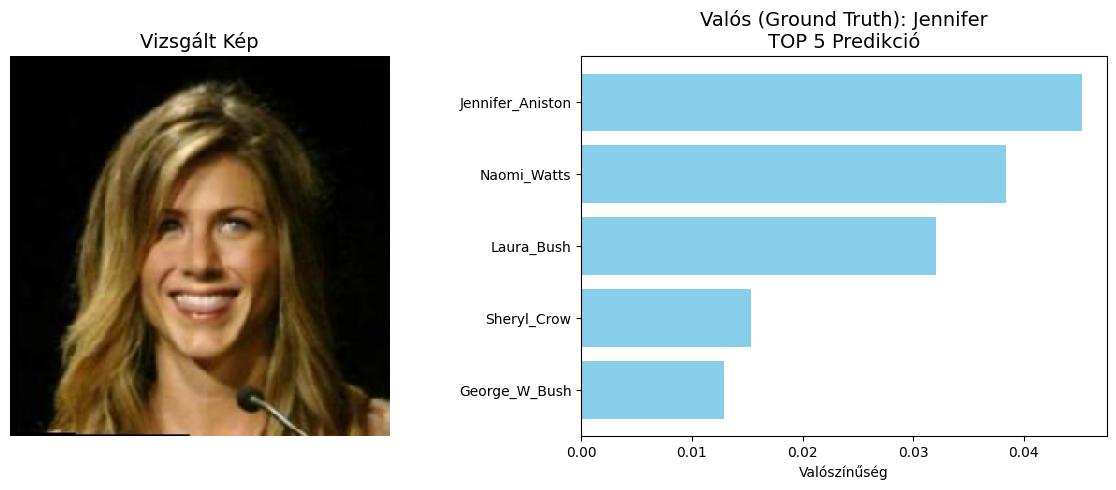

In [109]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Jennifer_Aniston/Jennifer_Aniston_0005.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)

In [ ]:
# ----------------- TESZTELÉS ÉS VIZUALIZÁCIÓ -----------------

# FIGYELEM: CSERÉLD KI EZT AZ ÚTVONALAT A TÉNYLEGES KÉP ELÉRÉSI ÚTJÁRA!
# Példa: 'drive/MyDrive/LFW_Adatok/Test/Colin_Powell/Colin_Powell_0001.jpg'
TEST_IMAGE_PATH = 'drive/MyDrive/colab_notebooks/Python_mernoki_alk/lfw_deep_funneled/lfw_funneled/Liam_Neeson/Liam_Neeson_0001.jpg'

# Győződj meg róla, hogy az összes segédfüggvény (Cella 1) már lefutott!
visualize_prediction(model, TEST_IMAGE_PATH)